<a href="https://colab.research.google.com/github/Echester97/Machine_learning/blob/Main-branch/Wheat_and_chess_board_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np

**PROBLEM 1**  Number of wheat on a 2x2 square chess board

Represent a 2 x 2 square chessboard by ndarray and calculate the number of wheat in each square. After placing one wheat on the upper left square, proceed to two to the right, four to the lower left, and eight to the lower right.

Please modify the shape of the ndarray created with the sample code.

In [31]:
n_squares = 4
small_board_list = [1]
for _ in range(n_squares-1):
  small_board_list.append(2*small_board_list[-1])
chessboard = np.array(small_board_list).reshape(2,2)
print(f'Arrange wheat on a 2x2 chessboard(ndarray):{chessboard}')

Arrange wheat on a 2x2 chessboard(ndarray):[[1 2]
 [4 8]]


**PROBLEM 2** Expansion to n x m mass

Create a function that returns a ndarray containing the number of wheat on an nxm chess board. Then use this function to find the number of wheat on the 8x8 square chess board.



In [44]:
def chessboard_wheat(n:int, m:int) -> np.ndarray:
  '''
  Function that returns a ndarray containing the number of wheat on an nxm chess board.


  Detailed description of the function

  :param n: Number of rows in the chessboard
  :type n: int
  :param m: Number of columns in the chessboard
  :type m: int
  :raises TypeError: If n or m are not integers
  :raises ValueError: If n or m are not positive integers
  :raises ValueError: If n and m are not equal
  :return: A ndarray containing the number of wheat on an nxm chess board
  '''
  if not isinstance(n, int) or not isinstance(m,int):
    raise TypeError("n and m must be integers")
  if n <= 0 or m <= 0:
    raise ValueError("n and m must be positive integers")
  if not n==m:
    raise ValueError("n and m must be equal")

  small_board_list = [1]
  for _ in range(n*m-1):
    small_board_list.append(2*small_board_list[-1])
  chessboard = np.round(np.array(small_board_list).reshape(n,m), 2)
  return chessboard
print(chessboard_wheat(8,8))

[[1.00000000e+00 2.00000000e+00 4.00000000e+00 8.00000000e+00
  1.60000000e+01 3.20000000e+01 6.40000000e+01 1.28000000e+02]
 [2.56000000e+02 5.12000000e+02 1.02400000e+03 2.04800000e+03
  4.09600000e+03 8.19200000e+03 1.63840000e+04 3.27680000e+04]
 [6.55360000e+04 1.31072000e+05 2.62144000e+05 5.24288000e+05
  1.04857600e+06 2.09715200e+06 4.19430400e+06 8.38860800e+06]
 [1.67772160e+07 3.35544320e+07 6.71088640e+07 1.34217728e+08
  2.68435456e+08 5.36870912e+08 1.07374182e+09 2.14748365e+09]
 [4.29496730e+09 8.58993459e+09 1.71798692e+10 3.43597384e+10
  6.87194767e+10 1.37438953e+11 2.74877907e+11 5.49755814e+11]
 [1.09951163e+12 2.19902326e+12 4.39804651e+12 8.79609302e+12
  1.75921860e+13 3.51843721e+13 7.03687442e+13 1.40737488e+14]
 [2.81474977e+14 5.62949953e+14 1.12589991e+15 2.25179981e+15
  4.50359963e+15 9.00719925e+15 1.80143985e+16 3.60287970e+16]
 [7.20575940e+16 1.44115188e+17 2.88230376e+17 5.76460752e+17
  1.15292150e+18 2.30584301e+18 4.61168602e+18 9.22337204e+18]]

**PROBLEM 3 ** Total number of wheat

Find the total number of wheat on a chess board of 8 x 8 squares. Also, finde the average of each column and visualize it in a bar chart

The total number of wheat in a 8x8 chessboard is 18446744073709551616


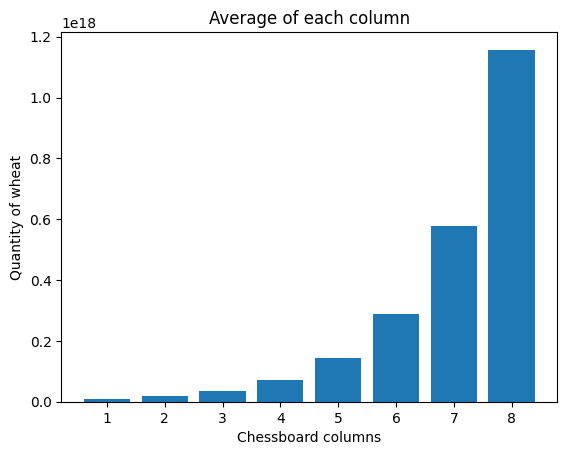

In [57]:
import matplotlib.pyplot as plt
%matplotlib inline
total_chessboard_wheat = np.sum(chessboard_wheat(8,8))
print(f'The total number of wheat in a 8x8 chessboard is {int(total_chessboard_wheat)}')
column_avg = np.mean(chessboard_wheat(8,8), axis=0)

plt.xlabel('Chessboard columns')
plt.ylabel('Quantity of wheat')
plt.title('Average of each column')
plt.bar(np.arange(1,9), column_avg)
plt.show()

**PROBLEM 4 Heat map of the number of wheat**

Visualize the number of wheat on the 8x8 chess board as a heat map.

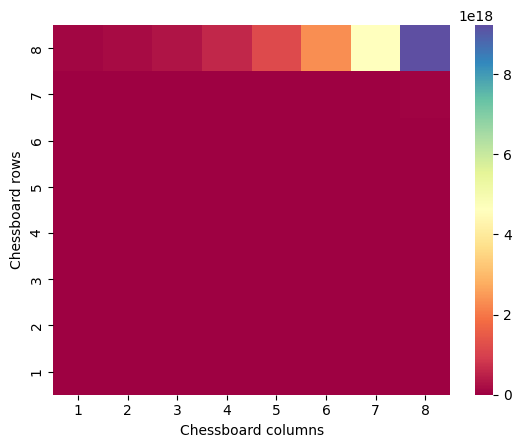

In [86]:
import seaborn as sns

ax =sns.heatmap(chessboard_wheat(8,8), cmap='Spectral', cbar_kws={'shrink': 1}, cbar=True)
plt.gca().invert_yaxis()
plt.xlabel('Chessboard columns')
ax.set_xticklabels(np.arange(1,9))
plt.ylabel('Chessboard rows')
ax.set_yticklabels(np.arange(1,9))
plt.show()

**PROBLEM 5** How many times is the second half as long as the first half?


In [93]:
cb_wheat = chessboard_wheat(8,8)
first_half_wheat = np.sum(cb_wheat[:4])
second_half_wheat = np.sum(cb_wheat[4:])
relation = second_half_wheat/first_half_wheat

print(f'The number of wheat in the second half is {relation} times higher')


The number of wheat in the second half is 4294967296.0 times higher


**PROBLEM 6** Expansion to n x m mass by another calculation method

Create a new function similar to Problem 2 that returns an ndarray containing the number of wheat squares on an nxm chessboard, one using the np.append() and one using broadcast.

Use those functions again to find the number of wheat on an 8x8 square chess board.

**PROBLEM 7** Comparing calculation times with %% time it

In [98]:
%%timeit
def chessboard_wheat(n:int, m:int) -> np.ndarray:
  '''
  Function that returns a ndarray containing the number of wheat on an nxm chess board.


  Detailed description of the function

  :param n: Number of rows in the chessboard
  :type n: int
  :param m: Number of columns in the chessboard
  :type m: int
  :raises TypeError: If n or m are not integers
  :raises ValueError: If n or m are not positive integers
  :raises ValueError: If n and m are not equal
  :return: A ndarray containing the number of wheat on an nxm chess board
  '''
  if not isinstance(n, int) or not isinstance(m,int):
    raise TypeError("n and m must be integers")
  if n <= 0 or m <= 0:
    raise ValueError("n and m must be positive integers")
  if not n==m:
    raise ValueError("n and m must be equal")

  small_board_list = [1]
  for _ in range(n*m-1):
    small_board_list.append(2*small_board_list[-1])
  chessboard = np.round(np.array(small_board_list).reshape(n,m), 2)
  return chessboard
print(chessboard_wheat(8,8))
print(np.sum(chessboard_wheat(8,8)))

Выходные данные были обрезаны до нескольких последних строк (5000).
1.8446744073709552e+19
[[1.00000000e+00 2.00000000e+00 4.00000000e+00 8.00000000e+00
  1.60000000e+01 3.20000000e+01 6.40000000e+01 1.28000000e+02]
 [2.56000000e+02 5.12000000e+02 1.02400000e+03 2.04800000e+03
  4.09600000e+03 8.19200000e+03 1.63840000e+04 3.27680000e+04]
 [6.55360000e+04 1.31072000e+05 2.62144000e+05 5.24288000e+05
  1.04857600e+06 2.09715200e+06 4.19430400e+06 8.38860800e+06]
 [1.67772160e+07 3.35544320e+07 6.71088640e+07 1.34217728e+08
  2.68435456e+08 5.36870912e+08 1.07374182e+09 2.14748365e+09]
 [4.29496730e+09 8.58993459e+09 1.71798692e+10 3.43597384e+10
  6.87194767e+10 1.37438953e+11 2.74877907e+11 5.49755814e+11]
 [1.09951163e+12 2.19902326e+12 4.39804651e+12 8.79609302e+12
  1.75921860e+13 3.51843721e+13 7.03687442e+13 1.40737488e+14]
 [2.81474977e+14 5.62949953e+14 1.12589991e+15 2.25179981e+15
  4.50359963e+15 9.00719925e+15 1.80143985e+16 3.60287970e+16]
 [7.20575940e+16 1.44115188e+17 2.

In [106]:
%%timeit
def chessboard_wheat(n:int, m:int) -> np.ndarray:
  '''
  Function that returns a ndarray containing the number of wheat on an nxm chess board.


  Detailed description of the function

  :param n: Number of rows in the chessboard
  :type n: int
  :param m: Number of columns in the chessboard
  :type m: int
  :raises TypeError: If n or m are not integers
  :raises ValueError: If n or m are not positive integers
  :raises ValueError: If n and m are not equal
  :return: A ndarray containing the number of wheat on an nxm chess board
  '''
  if not isinstance(n, int) or not isinstance(m,int):
    raise TypeError("n and m must be integers")
  if n <= 0 or m <= 0:
    raise ValueError("n and m must be positive integers")
  if not n==m:
    raise ValueError("n and m must be equal")

  small_board_ndarray = np.array([1]).astype(np.uint64)
  for _ in range(n*m-1):
    small_board_ndarray = np.append(small_board_ndarray, 2*small_board_ndarray[-1])
  chessboard = small_board_ndarray.reshape(n,m)
  return chessboard
print(chessboard_wheat(8,8))
print(np.sum(chessboard_wheat(8,8)))

Выходные данные были обрезаны до нескольких последних строк (5000).
                    8                  16                  32
                   64                 128]
 [                256                 512                1024
                 2048                4096                8192
                16384               32768]
 [              65536              131072              262144
               524288             1048576             2097152
              4194304             8388608]
 [           16777216            33554432            67108864
            134217728           268435456           536870912
           1073741824          2147483648]
 [         4294967296          8589934592         17179869184
          34359738368         68719476736        137438953472
         274877906944        549755813888]
 [      1099511627776       2199023255552       4398046511104
        8796093022208      17592186044416      35184372088832
       70368744177664     140737488

In [105]:
%%timeit
def chessboard_wheat(n:int, m:int) -> np.ndarray:
  '''
  Function that returns a ndarray containing the number of wheat on an nxm chess board.


  Detailed description of the function

  :param n: Number of rows in the chessboard
  :type n: int
  :param m: Number of columns in the chessboard
  :type m: int
  :raises TypeError: If n or m are not integers
  :raises ValueError: If n or m are not positive integers
  :raises ValueError: If n and m are not equal
  :return: A ndarray containing the number of wheat on an nxm chess board
  '''
  if not isinstance(n, int) or not isinstance(m,int):
    raise TypeError("n and m must be integers")
  if n <= 0 or m <= 0:
    raise ValueError("n and m must be positive integers")
  if not n==m:
    raise ValueError("n and m must be equal")

  indices_ndarray = np.arange(n*m).astype(np.uint64)
  board_ndarray = 2**indices_ndarray
  chessboard = board_ndarray.reshape(n,m)
  return chessboard
print(chessboard_wheat(8,8))
print(np.sum(chessboard_wheat(8,8)))

Выходные данные были обрезаны до нескольких последних строк (5000).
                    8                  16                  32
                   64                 128]
 [                256                 512                1024
                 2048                4096                8192
                16384               32768]
 [              65536              131072              262144
               524288             1048576             2097152
              4194304             8388608]
 [           16777216            33554432            67108864
            134217728           268435456           536870912
           1073741824          2147483648]
 [         4294967296          8589934592         17179869184
          34359738368         68719476736        137438953472
         274877906944        549755813888]
 [      1099511627776       2199023255552       4398046511104
        8796093022208      17592186044416      35184372088832
       70368744177664     140737488